## Loading and Testing CUDA

In [12]:
import os

# Check CUDA version using nvidia-smi
!nvidia-smi

# Or for a more specific CUDA toolkit version if available
!nvcc --version

Fri Apr  3 07:45:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             32W /   70W |    5379MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Installing Requirements

In [ ]:
# Colab cell: run as a code cell
# 1) Upgrade pip and install CPU PaddlePaddle 3.3.1 wheel, PaddleOCR with doc-parser extras, and HF tools.
# 2) Then force a runtime restart so the newly installed Paddle is loaded cleanly.

!python -m pip install --upgrade pip setuptools wheel

# Install PaddlePaddle GPU wheel with specific version and CUDA compatibility
# Using the command provided by the user for PaddlePaddle 3.3.0 with CUDA 13.0.
!python -m pip install paddlepaddle-gpu==3.3.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu130/

# Install PaddleOCR with doc-parser extras and supporting libs
!python -m pip install -U "paddleocr[doc-parser]"

# Hugging Face utilities and safetensors (normal pip package is fine for CPU)
!python -m pip install -U huggingface_hub transformers safetensors

# Force a runtime restart so the new paddle package is used (Colab will reconnect)
import os, sys, time
print("Installed packages. Restarting runtime to load PaddlePaddle...")
time.sleep(2)
os.kill(os.getpid(), 9)

## Paddle Check

In [13]:
# After runtime restarts, run this cell.
import os
import paddle
from paddleocr import PaddleOCRVL, PaddleOCR
from PIL import Image, ImageOps
import json
import pathlib

print("Paddle version:", paddle.__version__)

# Set device based on GPU availability

if paddle.is_compiled_with_cuda():
    paddle.set_device('gpu')
    print("Paddle device set to GPU.")
    # Run a simple check to verify GPU functionality
    try:
        paddle.utils.run_check()
        print("PaddlePaddle GPU check passed.")
    except Exception as e:
        print(f"PaddlePaddle GPU check failed: {e}")
        print("Falling back to CPU.")
        paddle.set_device('cpu')
else:
    print("No GPU found, falling back to CPU. Please ensure you have selected a GPU runtime (Runtime -> Change runtime type -> Hardware accelerator -> GPU).")
    paddle.set_device('cpu')

# Create workspace
WORKDIR = "/content/paddleocr_vl_workspace"
pathlib.Path(WORKDIR).mkdir(parents=True, exist_ok=True)
print("Workspace:", WORKDIR)

Paddle version: 3.3.0
Paddle device set to GPU.
Running verify PaddlePaddle program ... 
PaddlePaddle works well on 1 GPU.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.
PaddlePaddle GPU check passed.
Workspace: /content/paddleocr_vl_workspace


## Setup local image location - and Check


In [14]:
# Using a local demo image for PaddleOCR-VL

local_demo = os.path.join(WORKDIR, "demo.png")

# Check if the demo image exists locally
if os.path.exists(local_demo):
  print("Demo image found locally.")
else:
  # If the image is not found locally, raise an error as requested
  raise FileNotFoundError(f"Local demo image not found at {local_demo}. Please ensure the image is present.")

# If you want to upload your own image via Colab UI, run this:
# from google.colab import files
# uploaded = files.upload()
# for fn in uploaded: print("Uploaded:", fn)

Demo image found locally.


## Downloading model weights

In [5]:
# Run the PaddleOCRVL pipeline on the remote demo image (will download model weights on first run)
print("Instantiating PaddleOCRVL pipeline (this may download model weights; CPU inference will be slow)...")
pipeline = PaddleOCRVL(pipeline_version="v1")   # recommended API


Creating model: ('PP-DocLayoutV2', None)
Using official model (PP-DocLayoutV2), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-DocLayoutV2`.


Instantiating PaddleOCRVL pipeline (this may download model weights; CPU inference will be slow)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PaddleOCR-VL-0.9B', None)
Using official model (PaddleOCR-VL), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PaddleOCR-VL`.


Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading configuration file /root/.paddlex/official_models/PaddleOCR-VL/config.json
Loading weights file /root/.paddlex/official_models/PaddleOCR-VL/model.safetensors
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_heads: 16- num_key_value_heads: 2
use GQA - num_head

## Running PaddleOCR-VLM model - on local demo.png

In [15]:

print("Running prediction on demo URL...")
results = pipeline.predict(local_demo)

# results is typically a list of result objects; print summary
print("Number of results returned:", len(results))
for i, r in enumerate(results):
    print(f"--- Result {i} ---")
    # r is a structured object; try to print its string repr and save to files if methods exist
    try:
        print(r)
    except Exception:
        print("Could not print result object directly; converting to dict if possible.")
    # Save JSON/markdown if supported
    try:
        json_path = os.path.join(WORKDIR, f"paddleocr_vl_output_{i}.json")
        md_path = os.path.join(WORKDIR, f"paddleocr_vl_output_{i}.md")
        r.save_to_json(save_path=json_path)
        r.save_to_markdown(save_path=md_path)
        print("Saved:", json_path, md_path)
    except Exception as e:
        print("Save methods not available or failed:", e)


Running prediction on demo URL...


/usr/local/lib/python3.12/dist-packages/paddle/tensor/creation.py:1152: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach(), rather than paddle.to_tensor(sourceTensor).
  return tensor(


Number of results returned: 1
--- Result 0 ---
{'input_path': '/content/paddleocr_vl_workspace/demo.png', 'page_index': None, 'page_count': None, 'width': 750, 'height': 1061, 'doc_preprocessor_res': {'output_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], dtype=uint8)}, 'layout_det_res': {'input_path': None, 'page_index': None, 'input_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], dtype=uint8), 'boxes': [{'cls_id': 17, 'label': 'paragraph_title', 'score': 0.6013545393943787, 'coordinate': [56, 73, 287, 123], 'order': 1}, {'cls_id': 13, 'label': 'header_image', 'score': 0.6742841601371765, 'coordinate': [606, 47, 697, 138], 'order': None}, {'cls_id': 22, 'label': 'text', 'score': 0.900769829750061, 'coordinate': [52, 171, 100, 193], 'order': 2}, {'cls_id': 22, 'label': 'text', 'score': 

## LIGHTWEIGHT PaddleOCR
## Downloading English Invoice for PaddleOCR
(This will overwrite the existing `demo.png` to ensure English OCR works correctly)

In [29]:
import urllib.request

# URL for a known good English invoice image (trying a different branch/path)
demo_url_english = "https://templates.invoicehome.com/invoice-template-us-dexter-750px.png" # Updated URL

# Overwrite the existing local_demo with the English invoice
urllib.request.urlretrieve(demo_url_english, local_demo)
print("Overwritten demo.png with English invoice demo image to:", local_demo)

# Note: If you want to use a *different* image for VLM tests in the future,
# you would need to redefine `local_demo` or re-download the original VLM demo.

Overwritten demo.png with English invoice demo image to: /content/paddleocr_vl_workspace/demo.png


In [30]:
# If you want a lighter-weight OCR test (not VLM), use the classic PaddleOCR pipeline:
print("Running classic PaddleOCR (det + rec) as a fallback quick test...")
ocr = PaddleOCR(use_angle_cls=True, lang="en")  # loads detection+recognition models
res = ocr.ocr(local_demo)
print("Classic PaddleOCR extracted text:")

# Iterate through the results to print text line by line
for page_result in res:
    if 'rec_texts' in page_result:
        for text_info in page_result['rec_texts']:
            print(text_info[0]) # Print only the text part

/tmp/ipykernel_7493/1985602254.py:3: DeprecationWarning: The parameter `use_angle_cls` has been deprecated and will be removed in the future. Please use `use_textline_orientation` instead.
  ocr = PaddleOCR(use_angle_cls=True, lang="en")  # loads detection+recognition models
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Running classic PaddleOCR (det + rec) as a fallback quick test...


Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.
/tmp/ipykernel_7493/1985602254.py:4: DeprecationWarning: Please use `predict` instead.
  res = ocr.ocr(local_demo)


Classic PaddleOCR extracted text:
I
E
1
N
B
S
I
J
U
J
2
I
3
1
N
C
P
2
D
2
Q
D
U
A
1
F
1
1
1
3
2
N
5
1
3
L
S
1
S
9
T
$
J
T
P
P


Visualizing detected text boxes...


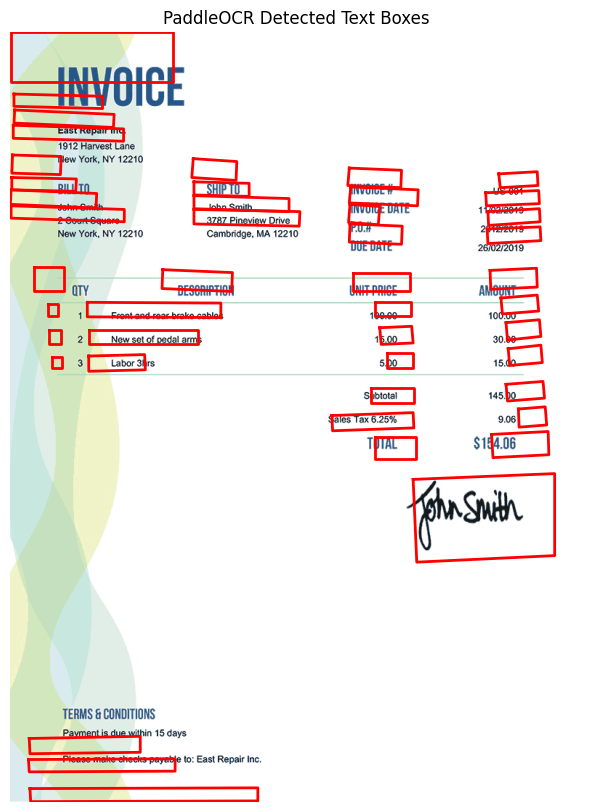

In [32]:
import matplotlib.pyplot as plt
from PIL import Image

# Assuming `local_demo` is the path to your image and `paddle_results` is the output from ocr.ocr(local_demo)

def draw_ocr_results(image_path, results):
    img = Image.open(image_path).convert('RGB')
    plt.figure(figsize=(10, 10))
    plt.imshow(img)

    for page_result in results:
        if 'dt_polys' in page_result:
            for box in page_result['dt_polys']:
                # Convert the box coordinates to a format suitable for matplotlib
                # box is a list of 4 points: [[x1, y1], [x2, y2], [x3, y3], [x4, y4]]
                # We need to close the polygon for plotting
                xs = [p[0] for p in box] + [box[0][0]]
                ys = [p[1] for p in box] + [box[0][1]]
                plt.plot(xs, ys, 'r-', linewidth=2) # Draw red rectangles

    plt.title('PaddleOCR Detected Text Boxes')
    plt.axis('off')
    plt.show()

print("Visualizing detected text boxes...")
draw_ocr_results(local_demo, paddle_results)


In [34]:
import paddle
import paddleocr # Import the module directly

print("PaddlePaddle version:", paddle.__version__)
print("PaddleOCR version:", paddleocr.__version__)

PaddlePaddle version: 3.3.0
PaddleOCR version: 3.4.0


## Testing OLLAMA API Chat

In [ ]:
import requests
import json

# Your Cloudflare Tunnel URL
CLOUDFLARE_URL = "https://post-coding-cruise-tuesday.trycloudflare.com"
MODEL = "llama3.1"  # Ensure this model is pulled on the host machine

def continuous_chat_via_generate():
    context = None  # This stores the "memory" of the chat

    print(f"--- Continuous Chat (via Generate Endpoint) ---")
    print("Type 'quit' to stop.\n")

    while True:
        user_input = input("You: ")

        if user_input.lower() in ['quit', 'exit']:
            break

        payload = {
            "model": MODEL,
            "prompt": user_input,
            "stream": False,
            "context": context  # Send the memory back to Ollama
        }

        try:
            response = requests.post(f"{CLOUDFLARE_URL}/api/generate", json=payload)
            response.raise_for_status()

            data = response.json()

            # Print the AI response
            print(f"AI: {data['response']}\n")

            # Update the context (this is an array of numbers that represents the conversation)
            context = data.get('context')

        except Exception as e:
            print(f"\nError: {e}")
            break

if __name__ == "__main__":
    continuous_chat_via_generate()

## JSON AI


In [35]:
import json
import os

# Ensure json_path is defined, it should be from previous cells
# json_path = os.path.join(WORKDIR, "paddleocr_vl_output_0.json")

# Read the .json file
with open(json_path, 'r') as f:
    ocr_vl_data = json.load(f)

print(f"Successfully loaded JSON from: {json_path}")

Successfully loaded JSON from: /content/paddleocr_vl_workspace/paddleocr_vl_output_0.json


In [38]:
def extract_and_combine_content(data):
    combined_content = []
    if isinstance(data, list) and data:
        # Assuming the structure has a parsing_res_list within the first item
        if 'parsing_res_list' in data[0] and isinstance(data[0]['parsing_res_list'], list):
            for item in data[0]['parsing_res_list']:
                # Access 'content' as an attribute of the PaddleOCRVLBlock object
                if hasattr(item, 'content') and item.content is not None:
                    combined_content.append(item.content)
    return '\n'.join(combined_content)

# Extract and combine the 'content' from the loaded JSON data
# Using 'results' directly which holds the full parsed output from the PaddleOCRVL pipeline.
extracted_block_contents = extract_and_combine_content(results)

print("\n--- Extracted Block Contents ---")
print(extracted_block_contents)


--- Extracted Block Contents ---
invoice

FROM
East Repair Inc.
1912 Harvest Lane
New York, NY 12210
BILL TO
John Smith
2 Court Square
New York, NY 12210
SHIP TO
John Smith
3787 Pineview Drive
Cambridge, MA 12210
INVOICE # US-001
INVOICE DATE 11/02/2019
P.O.# 2312/2019
DUE DATE 26/02/2019

<table><tr><td>QTY</td><td>DESCRIPTION</td><td>UNIT</td><td>PRICE</td><td>AMOUNT</td></tr><tr><td>1</td><td>Front and rear brake cables</td><td>100.00</td><td></td><td>100.00</td></tr><tr><td>2</td><td>New set of pedal arms</td><td>15.00</td><td></td><td>30.00</td></tr><tr><td>3</td><td>Labor 3hrs</td><td>5.00</td><td></td><td>15.00</td></tr></table>
Subtotal 145.00
Sales Tax 6.25% 9.06
TOTAL
TERMS & CONDITIONS
Payment is due within 15 days
John Smith
Please make checks payable to: East Repair Inc.


In [43]:
import requests
import json

# Ensure CLOUDFLARE_URL and MODEL are defined from previous cells
CLOUDFLARE_URL = "https://newsletters-para-represent-rats.trycloudflare.com"
MODEL = "llama3.1"

# Define the custom prompt with the desired JSON format
custom_prompt = f"""Extract the following information from the text below and return it as a JSON object. If a field is not found, use null. Convert currency values (e.g., $100.00) to float numbers (e.g., 100.00). Ensure the output is only the JSON object, with no additional text or formatting. Dates should be in YYYY-MM-DD format.

Desired JSON format example:
```json
{{
  "Person_name": "string",
  "Company_name": "string",
  "address": "string",
  "contact": "string",
  "invoice_number": "string",
  "invoice_date": "DD-MM-YYYY",
  "due_date": "DD-MM-YYYY",
  "subtotal": "float",
  "tax": "float",
  "total": "float"
}}
```

Text to process:
{extracted_block_contents}

Please provide the JSON object directly, with no surrounding text or markdown. Example: {{ "name": "..." }}"""

payload = {
    "model": MODEL,
    "prompt": custom_prompt,
    "stream": False
}

try:
    print("\n--- Calling Ollama API with custom prompt ---")
    response = requests.post(f"{CLOUDFLARE_URL}/api/generate", json=payload)
    response.raise_for_status() # Raise an exception for HTTP errors

    data = response.json()

    # Print only the AI response, which should be the JSON object
    print("\n--- Ollama API Response (JSON Output) ---")
    print(data['response'])

except requests.exceptions.RequestException as e:
    print(f"\nError during API call: {e}")
except json.JSONDecodeError:
    print("\nError: Could not decode JSON response from Ollama API.")
    print(f"Raw response text: {response.text}")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")


--- Calling Ollama API with custom prompt ---

--- Ollama API Response (JSON Output) ---
{
  "Person_name": "John Smith",
  "Company_name": "East Repair Inc.",
  "address": "1912 Harvest Lane, New York, NY 12210",
  "contact": null,
  "invoice_number": "US-001",
  "invoice_date": "02-11-2019",
  "due_date": "02-26-2019",
  "subtotal": 145.00,
  "tax": 9.06,
  "total": null
}


In [ ]:

# --- Calling Ollama API with custom prompt ---

# --- Ollama API Response (JSON Output) ---
# {
#     "name": "East Repair Inc.",
#     "address": "1912 Harvest Lane New York, NY 12210",
#     "contact": null,
#     "invoice_number": "US-001",
#     "invoice_date": "2019-11-02",
#     "subtotal": 145.00,
#     "tax": 9.06,
#     "total": null
# }

In [45]:
import requests
import json

# Ensure CLOUDFLARE_URL and MODEL are defined from previous cells
CLOUDFLARE_URL = "https://newsletters-para-represent-rats.trycloudflare.com"
MODEL = "llama3.1"

# Define the custom prompt with the desired JSON format
custom_prompt = f"""Extract the following information from the text below and return it as a JSON object. If a field is not found, use null. Convert currency values (e.g., $100.00) to float numbers (e.g., 100.00). Ensure the output is only the JSON object, with no additional text or formatting. Dates should be in YYYY-MM-DD format.

Desired JSON format example:
```json
{{
  "Person_name": "string",
  "Company_name": "string",
  "address": "string",
  "contact": "string",
  "invoice_number": "string",
  "invoice_date": "DD-MM-YYYY",
  "due_date": "DD-MM-YYYY",
  "subtotal": "float",
  "tax": "float",
  "total": "float"
}}
```

Text to process:
{extracted_block_contents}

Please provide the JSON object directly, with no surrounding text or markdown. Example: {{ "name": "..." }}"""

payload = {
    "model": MODEL,
    "prompt": custom_prompt,
    "stream": False
}

try:
    print("\n--- Calling Ollama API with custom prompt ---")
    response = requests.post(f"{CLOUDFLARE_URL}/api/generate", json=payload)
    response.raise_for_status() # Raise an exception for HTTP errors

    data = response.json()

    # Print only the AI response, which should be the JSON object
    print("\n--- Ollama API Response (JSON Output) ---")
    print(data['response'])

except requests.exceptions.RequestException as e:
    print(f"\nError during API call: {e}")
except json.JSONDecodeError:
    print("\nError: Could not decode JSON response from Ollama API.")
    print(f"Raw response text: {response.text}")
except Exception as e:
    print(f"\nAn unexpected error occurred: {e}")


--- Calling Ollama API with custom prompt ---

--- Ollama API Response (JSON Output) ---
{
  "Person_name": "John Smith",
  "Company_name": "East Repair Inc.",
  "address": "2 Court Square New York, NY 12210",
  "contact": null,
  "invoice_number": "US-001",
  "invoice_date": "2019-11-02",
  "due_date": "2019-02-26",
  "subtotal": 145.00,
  "tax": 9.06,
  "total": null
}
